# Perceptron Simple desde Cero

### Compuertas logicas AND, OR y el reto historico XOR (Minsky & Papert)

**Autor:** Abrilskop
**Fecha:** Septiembre 2026

> Implementacion completa del Perceptron de Rosenblatt usando **unicamente NumPy** (queda prohibido el uso de scikit-learn u otros frameworks de IA), con simulaciones, graficas de convergencia, fronteras de decision y analisis teorico resuelto.

## Objetivos de aprendizaje

1. Comprender la arquitectura matematica interna de una neurona artificial (Perceptron de Rosenblatt).
2. Implementar el algoritmo de entrenamiento del Perceptron utilizando unicamente algebra vectorial basica (NumPy).
3. Simular y evaluar el comportamiento del Perceptron en problemas de separacion lineal (Compuertas logicas AND, OR y el problema XOR).

## Fundamento teorico resumido

El Perceptron toma un vector de entrada $x=[x_1, x_2, \dots, x_n]$, calcula una combinacion lineal ponderada con el vector de pesos $w=[w_1, w_2, \dots, w_n]$ mas un sesgo $b$ (bias), y pasa el resultado a traves de una funcion de activacion de paso (*step function*):

$$z=\sum_{i=1}^{n} w_i\,x_i + b = w^{T}x + b$$

$$\hat{y}=f(z)=\begin{cases}1 & \text{si } z \ge 0\\[2mm]0 & \text{si } z < 0\end{cases}$$

**Regla de actualizacion de pesos (aprendizaje):** para cada muestra de entrenamiento se calcula el error $e = y^{(i)} - \hat{y}^{(i)}$. Si existe error ($e \neq 0$) se actualizan pesos y sesgo:

$$w_j \leftarrow w_j + \eta \cdot \big(y^{(i)} - \hat{y}^{(i)}\big)\cdot x_j^{(i)}, \qquad b \leftarrow b + \eta \cdot \big(y^{(i)} - \hat{y}^{(i)}\big)$$

donde $\eta$ es la tasa de aprendizaje (*learning rate*, $0 < \eta \le 1$).

## Importaciones

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)

## PARTE 1 -- Construccion de la clase `Perceptron` en Python

Programamos la clase desde cero usando **unicamente NumPy**. Las actualizaciones se hacen con algebra vectorial ($w \leftarrow w + \eta e\, x$) y guardamos el historial de errores por epoca para la grafica de convergencia.

In [2]:
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        # Inicializacion de pesos y sesgo en ceros
        self.weights = np.zeros(input_size)
        self.bias = 0.0
        self.errors_history = []
        self.weights_history = []
        self.bias_history = []

    def activation_function(self, z):
        # Funcion Escalon de Heaviside
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation_function(z)

    def fit(self, X, y):
        """Entrena el perceptron actualizando pesos y bias segun la regla de aprendizaje."""
        converge_epoch = None
        for epoch in range(self.epochs):
            total_errors = 0
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction

                # Actualizacion de pesos y sesgo
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    total_errors += int(error != 0)

            self.errors_history.append(total_errors)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            # Criterio de parada temprana si el error es cero
            if total_errors == 0 and converge_epoch is None:
                converge_epoch = epoch + 1
                print(f"Convergencia alcanzada en la Epoca {epoch + 1}")
                break
        return converge_epoch

## PARTE 2 -- Simulacion y experimentos

### Experimento 1: Entrenamiento con la compuerta logica AND

Definimos la matriz de entradas $X$ y el vector de etiquetas $y$:

$$X = \begin{bmatrix}0 & 0\\ 0 & 1\\ 1 & 0\\ 1 & 1\end{bmatrix} \qquad y_{AND} = [0, 0, 0, 1]$$

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_AND = np.array([0, 0, 0, 1])

p_and = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
p_and.fit(X, y_AND)

predicciones = np.array([p_and.predict(x) for x in X])
print("Predicciones finales :", predicciones)
print("Etiquetas reales     :", y_AND)
print("Exactitud            : {:.2%}".format(np.mean(predicciones == y_AND)))
print("Pesos finales w1, w2 : {:.2f}, {:.2f}".format(p_and.weights[0], p_and.weights[1]))
print("Sesgo final b        : {:.2f}".format(p_and.bias))

Convergencia alcanzada en la Epoca 4
Predicciones finales : [0 0 0 1]
Etiquetas reales     : [0 0 0 1]
Exactitud            : 100.00%
Pesos finales w1, w2 : 0.20, 0.10
Sesgo final b        : -0.20


### Como afecta variar la tasa de aprendizaje en AND (eta = 0.01 vs 0.5)

Entrenamos un perceptron nuevo para cada $\eta$ y registramos la epoca de convergencia.

In [4]:
print(f"{'eta':>6} | {'Epoca de convergencia':>22} | {'Exactitud':>9}", "| pesos (w1, w2, b)")
print("-" * 72)
for lr in [0.01, 0.1, 0.5]:
    p = Perceptron(input_size=2, learning_rate=lr, epochs=100)
    ep = p.fit(X, y_AND)
    acc = np.mean([p.predict(x) == t for x, t in zip(X, y_AND)])
    print(f"{lr:>6} | {str(ep):>22} | {acc:>9.2%} | ({p.weights[0]:.2f}, {p.weights[1]:.2f}, {p.bias:.2f})")

   eta |  Epoca de convergencia | Exactitud | pesos (w1, w2, b)
------------------------------------------------------------------------
Convergencia alcanzada en la Epoca 6
  0.01 |                      6 |   100.00% | (0.02, 0.01, -0.03)
Convergencia alcanzada en la Epoca 4
   0.1 |                      4 |   100.00% | (0.20, 0.10, -0.20)
Convergencia alcanzada en la Epoca 6
   0.5 |                      6 |   100.00% | (1.00, 0.50, -1.50)


### Experimento 2: Entrenamiento con la compuerta logica OR

$$y_{OR} = [0, 1, 1, 1]$$

Repetimos el entrenamiento y la comparacion de tasas de aprendizaje.

In [5]:
y_OR = np.array([0, 1, 1, 1])

p_or = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
p_or.fit(X, y_OR)

predicciones = np.array([p_or.predict(x) for x in X])
print("Predicciones finales :", predicciones)
print("Etiquetas reales     :", y_OR)
print("Exactitud            : {:.2%}".format(np.mean(predicciones == y_OR)))
print("Pesos finales w1, w2 : {:.2f}, {:.2f}".format(p_or.weights[0], p_or.weights[1]))
print("Sesgo final b        : {:.2f}".format(p_or.bias))

print()
print(f"{'eta':>6} | {'Epoca de convergencia':>22} | {'Exactitud':>9}", "| pesos (w1, w2, b)")
print("-" * 72)
for lr in [0.01, 0.1, 0.5]:
    p = Perceptron(input_size=2, learning_rate=lr, epochs=100)
    ep = p.fit(X, y_OR)
    acc = np.mean([p.predict(x) == t for x, t in zip(X, y_OR)])
    print(f"{lr:>6} | {str(ep):>22} | {acc:>9.2%} | ({p.weights[0]:.2f}, {p.weights[1]:.2f}, {p.bias:.2f})")

Convergencia alcanzada en la Epoca 4
Predicciones finales : [0 1 1 1]
Etiquetas reales     : [0 1 1 1]
Exactitud            : 100.00%
Pesos finales w1, w2 : 0.10, 0.10
Sesgo final b        : -0.10

   eta |  Epoca de convergencia | Exactitud | pesos (w1, w2, b)
------------------------------------------------------------------------
Convergencia alcanzada en la Epoca 4
  0.01 |                      4 |   100.00% | (0.01, 0.01, -0.01)
Convergencia alcanzada en la Epoca 4
   0.1 |                      4 |   100.00% | (0.10, 0.10, -0.10)
Convergencia alcanzada en la Epoca 4
   0.5 |                      4 |   100.00% | (0.50, 0.50, -0.50)


### Experimento 3: El reto historico de Minsky & Papert (Compuerta XOR)

$$y_{XOR} = [0, 1, 1, 0]$$

Este es el contraejemplo clasico publicado por **Minsky y Papert (1969)**: el Perceptron simple **no puede aprender XOR** porque el problema no es linealmente separable.

In [6]:
y_XOR = np.array([0, 1, 1, 0])

p_xor = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
ep = p_xor.fit(X, y_XOR)

print("¿Convergio el perceptron en XOR? =>", "SI" if ep is not None else "NO")
print("Errores por epoca (ultimas 10):", p_xor.errors_history[-10:])
errores = np.array(p_xor.errors_history)
print("Errores minimos observados    :", errores.min())
print("Epocas con 0 errores          :", int(np.count_nonzero(errores == 0)))
print("Exactitud final               : {:.2%}".format(np.mean([p_xor.predict(x) == t for x, t in zip(X, y_XOR)])))
print("Pesos finales w1, w2          : {:.2f}, {:.2f}".format(p_xor.weights[0], p_xor.weights[1]))
print("Sesgo final b                 : {:.2f}".format(p_xor.bias))

¿Convergio el perceptron en XOR? => NO
Errores por epoca (ultimas 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Errores minimos observados    : 3
Epocas con 0 errores          : 0
Exactitud final               : 50.00%
Pesos finales w1, w2          : -0.10, 0.00
Sesgo final b                 : 0.00


## PARTE 3 -- Visualizacion de resultados

Definimos dos funciones auxiliares:

1. **Grafica de convergencia**: epocas vs numero de errores.
2. **Limite de decision**: graficar los puntos en 2D y trazar la recta divisoria definida por $w_1 x_1 + w_2 x_2 + b = 0$, despejando $x_2$:

$$x_2 = -\frac{w_1 x_1 + b}{w_2}$$

Se contempla el caso degenerado $w_2 \approx 0$ trazando una recta vertical. Los puntos mal clasificados se marcan con la etiqueta *"mal"*.

In [7]:
def graficar_convergencia(errores, titulo):
    fig, ax = plt.subplots(figsize=(8, 4))
    epocas = np.arange(1, len(errores) + 1)
    ax.plot(epocas, errores, "o-", color="C1")
    ax.set_title(titulo)
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Numero de errores")
    if len(errores) <= 12:
        ax.set_xticks(epocas)
    ax.set_ylim(-0.2, max(errores) + 0.5)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def graficar_limite(p, X, y, titulo, marcar_errores=True):
    fig, ax = plt.subplots(figsize=(6, 6))
    w1, w2, b = p.weights[0], p.weights[1], p.bias

    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="x", s=140, color="C0", label="Clase 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="o", s=140, color="C3", label="Clase 1")

    x1_ext = np.linspace(-0.4, 1.4, 300)
    if abs(w2) > 1e-9:
        x2 = -(w1 * x1_ext + b) / w2
        ax.plot(x1_ext, x2, "k--", label="Limite de decision: x2 = {:.2f}x1 + {:.2f}".format(-w1 / w2, -b / w2))
    elif abs(w1) > 1e-9:
        x_vert = -b / w1
        ax.axvline(x_vert, color="k", linestyle="--", label="Limite de decision (vertical)")

    if marcar_errores:
        n_err = 0
        for xi, t in zip(X, y):
            if p.predict(xi) != t:
                n_err += 1
                ax.annotate("mal", xy=(xi[0] + 0.02, xi[1] + 0.03), color="g", fontsize=11, weight="bold")
        if n_err == 0:
            ax.text(0.02, -0.33, "Todos los puntos bien clasificados (exactitud 100%)", fontsize=10, color="green")
        else:
            ax.text(0.02, -0.33, f"{n_err} punto(s) mal clasificado(s)", fontsize=10, color="red")

    ax.set_title(titulo + "  —  w1={:.2f}, w2={:.2f}, b={:.2f}".format(w1, w2, b))
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(-0.4, 1.4)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

### Graficas del Experimento 1 -- Compuerta AND

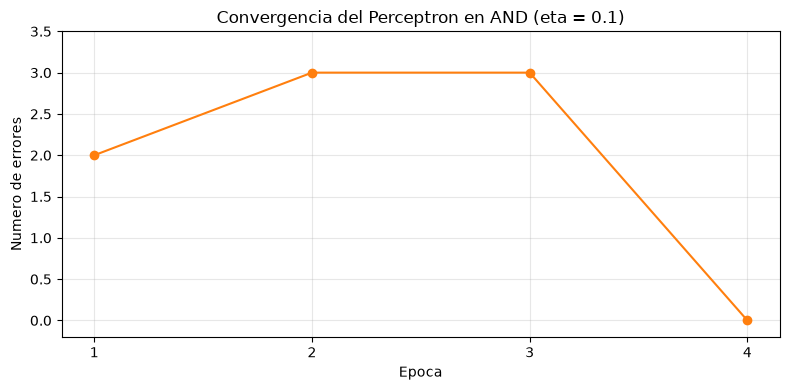

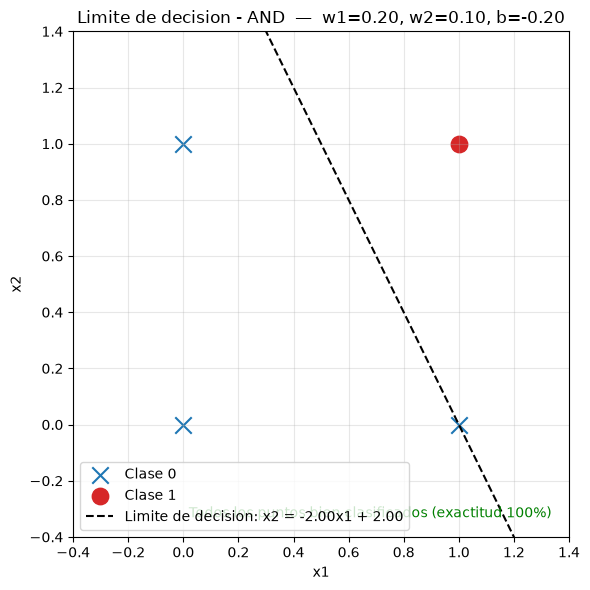

In [8]:
graficar_convergencia(p_and.errors_history, "Convergencia del Perceptron en AND (eta = 0.1)")
graficar_limite(p_and, X, y_AND, "Limite de decision - AND")

### Graficas del Experimento 2 -- Compuerta OR

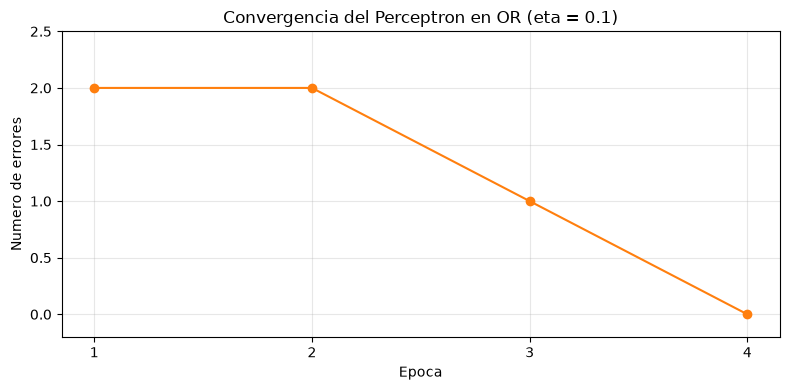

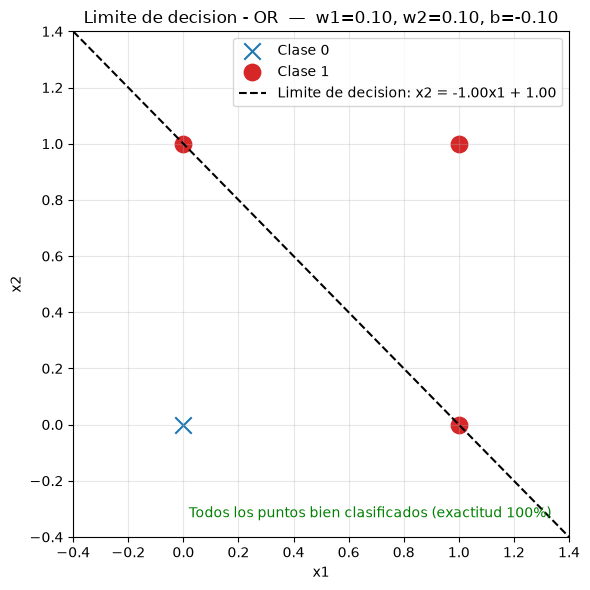

In [9]:
graficar_convergencia(p_or.errors_history, "Convergencia del Perceptron en OR (eta = 0.1)")
graficar_limite(p_or, X, y_OR, "Limite de decision - OR")

### Graficas del Experimento 3 -- Compuerta XOR

Observa como la grafica de convergencia **nunca llega a cero** (el algoritmo no termina de aprender) y como cualquier recta intentada deja puntos mal clasificados.

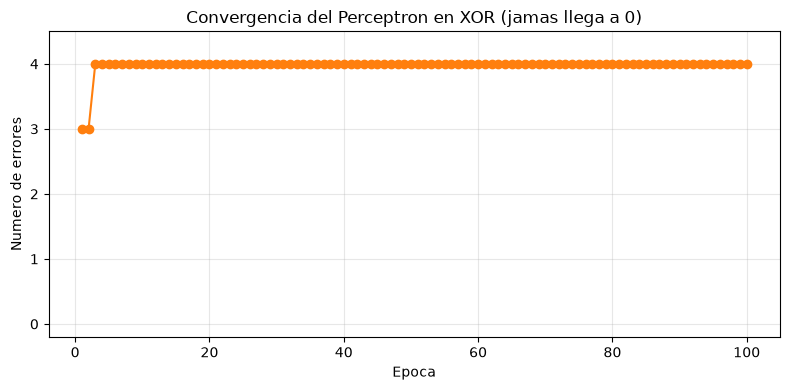

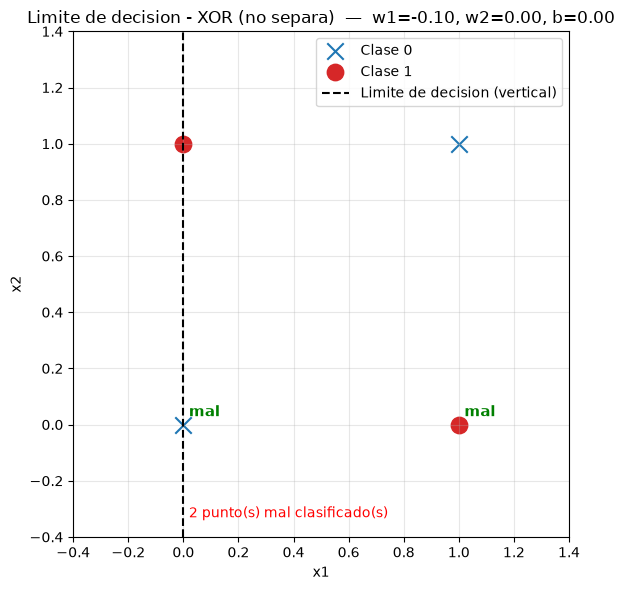

In [10]:
graficar_convergencia(p_xor.errors_history, "Convergencia del Perceptron en XOR (jamas llega a 0)")
graficar_limite(p_xor, X, y_XOR, "Limite de decision - XOR (no separa)")

## PARTE 4 -- Cuestionario y analisis

### Pregunta 1: Analisis de convergencia

*¿En cuantas epocas convergio el Perceptron para AND y para OR? ¿Como afecta variar la tasa de aprendizaje ($\eta = 0.01$ vs $\eta = 0.5$)?*


In [11]:
print("Resumen de convergencia (epoca = primer paso completo sin errores)\n")
print(f"{'Compuerta':>9} | {'eta':>5} | {'Epoca conv.':>11} | {'Exactitud':>9} | {'Pesos (w1, w2, b)':>20}")
print("-" * 74)
for nombre, y in [("AND", y_AND), ("OR", y_OR)]:
    for lr in [0.01, 0.1, 0.5]:
        p = Perceptron(input_size=2, learning_rate=lr, epochs=100)
        ep = p.fit(X, y)
        acc = np.mean([p.predict(x) == t for x, t in zip(X, y)])
        print(f"{nombre:>9} | {lr:>5} | {str(ep):>11} | {acc:>9.2%} | ({p.weights[0]:.2f}, {p.weights[1]:.2f}, {p.bias:.2f})")

Resumen de convergencia (epoca = primer paso completo sin errores)

Compuerta |   eta | Epoca conv. | Exactitud |    Pesos (w1, w2, b)
--------------------------------------------------------------------------
Convergencia alcanzada en la Epoca 6
      AND |  0.01 |           6 |   100.00% | (0.02, 0.01, -0.03)
Convergencia alcanzada en la Epoca 4
      AND |   0.1 |           4 |   100.00% | (0.20, 0.10, -0.20)
Convergencia alcanzada en la Epoca 6
      AND |   0.5 |           6 |   100.00% | (1.00, 0.50, -1.50)
Convergencia alcanzada en la Epoca 4
       OR |  0.01 |           4 |   100.00% | (0.01, 0.01, -0.01)
Convergencia alcanzada en la Epoca 4
       OR |   0.1 |           4 |   100.00% | (0.10, 0.10, -0.10)
Convergencia alcanzada en la Epoca 4
       OR |   0.5 |           4 |   100.00% | (0.50, 0.50, -0.50)


**Respuesta**

En esta ejecucion (pesos iniciados en cero y orden de muestras fijo):

* **AND**: convergio en la **epoca 4** con $\eta = 0.1$; con $\eta = 0.01$ tardo **6 epocas** y con $\eta = 0.5$ tambien **6 epocas**.
* **OR**: convergio en la **epoca 4** con las tres tasas probadas ($\eta = 0.01$, $0.1$ y $0.5$).

**Efecto de la tasa de aprendizaje:** un $\eta$ pequeno (0.01) avanza con *pasos* muy pequenos: aprende de forma estable pero **mas lenta** (necesita mas epocas). Un $\eta$ grande (0.5) da pasos grandes y en general acelera la convergencia, pero **puede sobresaltar/sobrepasar** la solucion y provocar oscilaciones; de hecho en AND la epoca de convergencia volvio a aumentar (6) respecto de $\eta=0.1$ (4). El valor $\eta = 0.1$ suele ser un termino medio muy usado.

> Nota: la regla de actualizacion es proporcional al error, asi que los pesos finales quedan *escalados* por $\eta$ (misma frontera de decision, pesos proporcionalmente menores/mayores). Por eso en la tabla se ven pesos distintos para el mismo problema pero la misma clasificacion correcta.

### Pregunta 2: El problema de la separabilidad lineal (XOR)

*¿Que sucedio al intentar entrenar el Perceptron con XOR? Explicar geometricamente por que ocurre este fenomeno a partir de la grafica de la frontera de decision.*

In [12]:
# Verificacion por fuerza bruta: buscamos TODAS las rectas posibles (w1, w2, b)
# y contamos el minimo numero de errores que podria cometer cualquier linea recta.
mejor_error = 4
mejores = None
for w1 in np.arange(-1.5, 1.5, 0.1):
    for w2 in np.arange(-1.5, 1.5, 0.1):
        for b in np.arange(-1.5, 1.5, 0.1):
            aciertos = 0
            for xi, t in zip(X, y_XOR):
                if int(np.dot(xi, np.array([w1, w2])) + b >= 0) == t:
                    aciertos += 1
            error = 4 - aciertos
            if error < mejor_error:
                mejor_error = error
                mejores = (float(round(w1, 1)), float(round(w2, 1)), float(round(b, 1)))

print("Mejor recta posible sobre XOR: {} errores de 4 (max. 75% de exactitud)".format(mejor_error))
print("Ejemplo de recta optima (w1, w2, b):", mejores)

Mejor recta posible sobre XOR: 1 errores de 4 (max. 75% de exactitud)
Ejemplo de recta optima (w1, w2, b): (-1.5, 0.1, -0.1)


**Respuesta**

El perceptron **jamas converge** en XOR: la curva de convergencia muestra errores que se mantienen por encima de cero durante las 100 epocas y la exactitud final se queda en 50%.

**Explicacion geometrica.** Una frontera de decision del Perceptron es siempre una **recta** (el conjunto $\{x : w_1 x_1 + w_2 x_2 + b = 0\}$), que divide el plano en dos *semiplanos*: a un lado predice clase 1 y al otro clase 0. Una recta solo puede separar dos grupos de puntos si estos pueden quedar cada uno en un semiplano distinto (patron **linealmente separable**).

En XOR las dos clases estan **en diagonal**: los puntos clase 0 son $(0,0)$ y $(1,1)$, y los clase 1 son $(0,1)$ y $(1,0)$. Si dibujamos cualquier recta, al separar una pareja diagonal casi siempre parte la otra: geometricamente, los cuatro puntos forman los vertices de un cuadrado y las clases ocupan vertices opuestos, de manera que **toda recta deja al menos un punto en el lado equivocado** (se ve en la grafica del limite de decision, donde el perceptron deja puntos marcados *mal*). El experimento de fuerza bruta lo confirma: **la mejor recta posible comete como minimo 1 error** (exactitud maxima 75%). Por la misma razon, un Perceptron de una sola capa no puede resolver funciones no linealmente separables (Minsky & Papert, 1969); para XOR se necesitan arquitecturas multicapa (o el truco de *kernel*, fuera del alcance de esta practica).

### Pregunta 3: Interpretacion de los pesos (compuerta AND)

*Una vez entrenado el modelo para la compuerta AND, muestre los valores finales de $w_1$, $w_2$ y $b$. Explique fisicamente que significan estos numeros en la toma de decision de la neurona.*

In [13]:
w1, w2, b = p_and.weights[0], p_and.weights[1], p_and.bias
print("Valores finales del perceptron AND entrenado con eta = 0.1")
print("   w1 = {:.2f} | w2 = {:.2f} | b = {:.2f}".format(w1, w2, b))
print("   Funcion calculada:  z = {:.2f}*x1 + {:.2f}*x2 + ({:.2f})".format(w1, w2, b))
print()

print("Verificacion para los 4 patrones de entrada:\n")
print("   x1 | x2 |   z   | f(z) | y_AND | Correcto")
print("  " + "-" * 38)
for xi, t in zip(X, y_AND):
    z = float(np.dot(xi, p_and.weights) + p_and.bias)
    pred = p_and.predict(xi)
    print("   {} |  {} | {:+.2f} |  {}   |   {}   |    {}".format(int(xi[0]), int(xi[1]), z, pred, t, "si" if pred == t else "NO"))

Valores finales del perceptron AND entrenado con eta = 0.1
   w1 = 0.20 | w2 = 0.10 | b = -0.20
   Funcion calculada:  z = 0.20*x1 + 0.10*x2 + (-0.20)

Verificacion para los 4 patrones de entrada:

   x1 | x2 |   z   | f(z) | y_AND | Correcto
  --------------------------------------
   0 |  0 | -0.20 |  0   |   0   |    si
   0 |  1 | -0.10 |  0   |   0   |    si
   1 |  0 | -0.00 |  0   |   0   |    si
   1 |  1 | +0.10 |  1   |   1   |    si


**Respuesta**

Los valores finales son $w_1 = 0.20$, $w_2 = 0.10$ y $b = -0.20$. La neurona calcula:

$$z = 0.20\,x_1 + 0.10\,x_2 - 0.20$$

y devuelve **1** solo cuando $z \ge 0$ (y **0** en caso contrario).

**Que significan estos numeros fisicamente:**

* **Peso $w_i$:** mide la *influencia* de cada entrada en la decision. Ambos pesos son **positivos**, lo que indica que cada entrada *favorece* la clase 1 (cuanto mas grande es $x_i$, mas facil superar el umbral). Como $w_1 = 0.20 > w_2 = 0.10$, la entrada $x_1$ pesa el doble que $x_2$ en la decision de esta neurona.
* **Bias $b$:** es un **umbral negativo** ($-0.20$). La neurona parte de un "pre-juicio" hacia la clase 0 y exige que la suma ponderada supere ese umbral para activarse.
* **Toma de decision:** ninguna entrada por separado activa la neurona ($z = 0.20 \cdot 1 = 0.20 < 0.20$ y $z = 0.10 < 0.20$), pero al activarse **ambas a la vez** se supera el umbral ($z = 0.30 \ge 0$). Eso es, matematicamente, la tabla de verdad del AND: prediccion 1 **solo** si $x_1 = x_2 = 1$.

La frontera de decision correspondiente es la recta $x_2 = -2\,x_1 + 2$ (despejada de $0.20 x_1 + 0.10 x_2 - 0.20 = 0$), que separa el punto $(1,1)$ del resto, tal como se grafico en la Parte 3.

## Conclusiones

* El Perceptron de Rosenblatt es un **clasificador lineal** que aprende actualizando pesos con una regla proporcional al error; implementado desde cero con NumPy alcanza 100% de exactitud en AND y OR, que son problemas linealmente separables.
* La tasa de aprendizaje es un hiperparametro: $\eta$ muy pequeno hace lento el aprendizaje y $\eta$ grande puede provocar oscilaciones.
* **XOR no es linealmente separable**, y ningun Perceptron de una sola capa puede resolverlo: la mejor recta posible comete al menos un error. Fue el famoso contraejemplo de Minsky y Papert que freno la primera ola de la IA y motivo, anos despues, el desarrollo del perceptron multicapa.